# Train a reusable intra-case autoencoder

This notebook trains **one autoencoder on many event logs** (the 60 logs in `data/autoencoder/`, generated by `data/autoencoder/generate_logs.py`) so that it can later be reused for intra-case drift detection on logs it has never seen.

The idea that makes this possible (taken from `pipeline_intra_autoencoders.ipynb`): every log is encoded into the **same fixed feature space**. We fix an alphabet of 20 possible activities (`a` … `t`) up front and define every feature column over that alphabet — regardless of which activities a particular log actually uses. Any log with at most 20 activities therefore always yields exactly the same 441 input features in the same order, and one trained network applies to all of them.

Steps:

1. encode every log into the fixed feature space (one vector per event)
2. split train/test **by log**, so the test set consists of entirely unseen processes
3. train the autoencoder (on CUDA or Apple MPS when available)
4. plot training/test losses and reconstruction errors
5. save the model + scaler and demonstrate reuse on a held-out log

In [1]:
import json
import string
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pm4py
import torch
import torch.nn as nn
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

## Configuration

In [20]:
DATA_DIR = Path("../data/autoencoder")

TRAIN_FRAC = 0.8   # fraction of the LOGS used for training, the rest is held out
HIDDEN_DIM = 256    # size of the hidden layers
LATENT_DIM = 64    # size of the bottleneck
EPOCHS = 25
BATCH_SIZE = 512
LR = 1e-3
SEED = 42

## Device

Training runs on an NVIDIA GPU (`cuda`) or an Apple Silicon GPU (`mps`) when available, otherwise on the CPU. Everything below only refers to `device`, so the same code runs on all three.

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

torch.manual_seed(SEED)
print(f"Using device: {device}")

Using device: mps


## The fixed feature space

The feature columns are defined once, over the full 20-letter alphabet — not over the activities of any particular log. A log that never uses activity `t` simply has zeros in all `t`-related columns. This is what keeps the input dimension constant across logs and makes the autoencoder reusable.

Per event (describing the case *prefix* up to and including that event):

| block | columns | meaning |
| --- | --- | --- |
| `freq_*` | 20 | how often each activity occurred among the events so far |
| `bigram_*` | 400 | how often each direct `x->y` transition occurred among the transitions so far |
| `seen_*` | 20 | whether each activity has occurred at all so far |
| `progress_ratio` | 1 | position of the event within its case (0–1] |

In [4]:
ACTIVITIES = list(string.ascii_lowercase[:20])                       # 'a' ... 't'
ALL_BIGRAMS = [f"{a}->{b}" for a in ACTIVITIES for b in ACTIVITIES]  # 400, incl. self-loops

FEATURE_COLS = (
    [f"freq_{a}" for a in ACTIVITIES]
    + [f"bigram_{b}" for b in ALL_BIGRAMS]
    + [f"seen_{a}" for a in ACTIVITIES]
    + ["progress_ratio"]
)
print(f"{len(FEATURE_COLS)} features per event")

441 features per event


## Encoding one log

Same computation as in `pipeline_intra_autoencoders.ipynb`, wrapped into a function: read the XES file, and for every event compute the prefix features. The `reindex(columns=..., fill_value=0)` calls force the fixed column set, no matter which activities the log contains.

In [5]:
def log_to_features(xes_path):
    """Encode one event log: one row of FEATURE_COLS per event, plus key columns."""
    df = pm4py.read_xes(str(xes_path), show_progress_bar=False)
    df = df.sort_values(["case:concept:name", "time:timestamp"]).reset_index(drop=True)

    case = df["case:concept:name"]
    activity = df["concept:name"]

    # position of each event within its case (1-based) and the case length
    event_pos = df.groupby(case).cumcount() + 1
    case_length = event_pos.groupby(case).transform("max")

    # how often each activity occurred among the events of the case so far
    activity_counts = pd.get_dummies(activity).reindex(columns=ACTIVITIES, fill_value=0)
    activity_counts = activity_counts.groupby(case).cumsum()
    activity_freq = activity_counts.div(event_pos, axis=0).add_prefix("freq_")

    # how often each direct x->y transition occurred among the transitions so far
    prev_activity = activity.groupby(case).shift(1)
    bigram = prev_activity + "->" + activity  # NaN for the first event of a case
    bigram_counts = pd.get_dummies(bigram).reindex(columns=ALL_BIGRAMS, fill_value=0)
    bigram_counts = bigram_counts.groupby(case).cumsum()
    n_transitions = (event_pos - 1).clip(lower=1)  # first event: avoid division by zero
    bigram_freq = bigram_counts.div(n_transitions, axis=0)
    bigram_freq[event_pos == 1] = 0  # no transitions yet at the first event
    bigram_freq = bigram_freq.add_prefix("bigram_")

    # which activities appeared at all so far + how far into the case we are
    seen = (activity_counts > 0).astype(int).add_prefix("seen_")
    progress = (event_pos / case_length).rename("progress_ratio")

    features = pd.concat([activity_freq, bigram_freq, seen, progress], axis=1)
    features = features[FEATURE_COLS].astype("float32")
    keys = df[["case:concept:name", "time:timestamp"]]
    return features, keys

## Load all logs

Encode every log in `data/autoencoder/` and stack the feature rows. We remember which log each row came from (`log_of_row`) for the split and the per-log evaluation. Takes a minute or two.

In [6]:
log_paths = sorted(DATA_DIR.glob("*.xes"))
print(f"{len(log_paths)} logs found")

frames, log_names, log_sizes = [], [], []
for path in log_paths:
    features, _ = log_to_features(path)
    frames.append(features)
    log_names.append(path.stem)
    log_sizes.append(len(features))

X_all = pd.concat(frames, ignore_index=True).to_numpy()
log_of_row = np.repeat(log_names, log_sizes)
del frames

print(f"{X_all.shape[0]} events x {X_all.shape[1]} features")

60 logs found
386641 events x 441 features


## Train/test split — by log

We hold out whole logs, not random events: the test set consists of processes the autoencoder has never seen. That is exactly the reuse scenario — apply the trained network to a new log without retraining.

In [7]:
rng = np.random.default_rng(SEED)
shuffled = rng.permutation(log_names).tolist()
train_logs = set(shuffled[: int(len(shuffled) * TRAIN_FRAC)])
test_logs = set(shuffled[int(len(shuffled) * TRAIN_FRAC):])

train_mask = np.isin(log_of_row, list(train_logs))
X_train = X_all[train_mask]
X_test = X_all[~train_mask]

print(f"train: {len(train_logs)} logs, {len(X_train)} events")
print(f"test:  {len(test_logs)} logs, {len(X_test)} events")
print("test logs:", sorted(test_logs))

train: 48 logs, 300209 events
test:  12 logs, 86432 events
test logs: ['intra_01', 'intra_02', 'intra_08', 'intra_12', 'intra_13', 'intra_14', 'intra_33', 'intra_36', 'intra_43', 'intra_45', 'intra_47', 'intra_58']


## Scaling

Standardize the features, fitted on the training logs only. The scaler is part of the trained artifact: a new log must be transformed with **this** scaler before it is fed to the autoencoder, so we save it together with the model at the end.

In [8]:
scaler = StandardScaler().fit(X_train)
X_train_t = torch.from_numpy(scaler.transform(X_train))
X_test_t = torch.from_numpy(scaler.transform(X_test))
X_train_t.shape, X_test_t.shape

(torch.Size([300209, 441]), torch.Size([86432, 441]))

In [19]:
X_train[:5, :5]

array([[1.        , 0.        , 0.        , 0.        , 0.        ],
       [0.5       , 0.5       , 0.        , 0.        , 0.        ],
       [0.33333334, 0.33333334, 0.        , 0.        , 0.        ],
       [0.25      , 0.25      , 0.        , 0.        , 0.        ],
       [0.2       , 0.2       , 0.        , 0.        , 0.        ]],
      dtype=float32)

## The autoencoder

Same architecture as in `pipeline_intra_autoencoders.ipynb`: a small MLP that compresses the 441 features through a bottleneck and reconstructs them. Events that look like the training data reconstruct well; unfamiliar behavior yields a high reconstruction error.

In [21]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z


model = Autoencoder(len(FEATURE_COLS), HIDDEN_DIM, LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()
model

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=441, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=441, bias=True)
  )
)

## Training

Plain minibatch training on the MSE reconstruction loss. After every epoch we also compute the loss on the held-out logs — that curve tells us how well the autoencoder generalizes to processes it was not trained on.

In [22]:
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_train_t), batch_size=BATCH_SIZE, shuffle=True
)
X_test_dev = X_test_t.to(device)

train_losses, test_losses = [], []
for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for (batch,) in loader:
        batch = batch.to(device)
        recon, _ = model(batch)
        loss = loss_fn(recon, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)
    train_losses.append(epoch_loss / len(X_train_t))

    model.eval()
    with torch.no_grad():
        recon, _ = model(X_test_dev)
        test_losses.append(loss_fn(recon, X_test_dev).item())

    if epoch == 1 or epoch % 5 == 0:
        print(f"epoch {epoch:3d}   train {train_losses[-1]:.4f}   test {test_losses[-1]:.4f}")

epoch   1   train 0.5181   test 0.2974
epoch   5   train 0.2481   test 0.2392
epoch  10   train 0.2253   test 0.2257
epoch  15   train 0.2155   test 0.2144
epoch  20   train 0.2102   test 0.2168
epoch  25   train 0.2061   test 0.2247


## Training and test loss

The test curve can sit below the train curve: it is computed on *different processes*, and how hard a log is to reconstruct depends far more on the process itself than on train/test membership (the per-log chart below makes that visible).

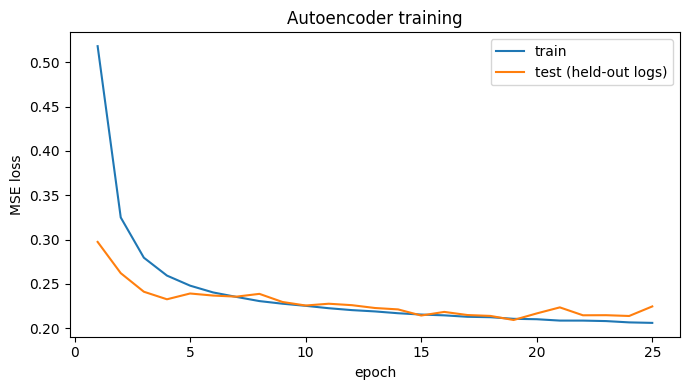

In [23]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, label="train")
plt.plot(range(1, EPOCHS + 1), test_losses, label="test (held-out logs)")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("Autoencoder training")
plt.legend()
plt.tight_layout()
plt.show()

## Reconstruction error per event

The helper below scores any feature tensor in chunks and returns one error per event; it is reused for the demo at the end. The histogram compares training and test events, the bar chart shows the mean error per log. The held-out logs land within the range of the training logs — differences between processes dominate over train/test membership, which is exactly what makes the autoencoder reusable: thanks to the shared feature space, unseen logs are scored just as meaningfully.

In [24]:
def reconstruction_errors(model, X_tensor, batch_size=4096):
    """Per-event mean squared reconstruction error."""
    model.eval()
    errors = []
    with torch.no_grad():
        for start in range(0, len(X_tensor), batch_size):
            batch = X_tensor[start:start + batch_size].to(device)
            recon, _ = model(batch)
            errors.append(((recon - batch) ** 2).mean(dim=1).cpu())
    return torch.cat(errors).numpy()


train_errors = reconstruction_errors(model, X_train_t)
test_errors = reconstruction_errors(model, X_test_t)

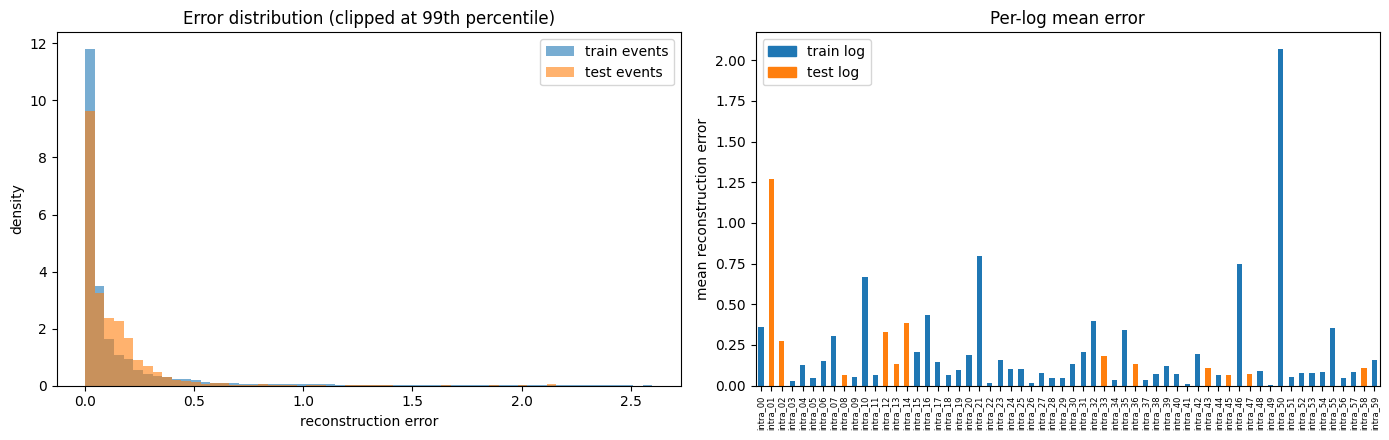

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

hi = np.quantile(np.concatenate([train_errors, test_errors]), 0.99)
bins = np.linspace(0, hi, 60)
ax1.hist(train_errors, bins=bins, alpha=0.6, density=True, label="train events")
ax1.hist(test_errors, bins=bins, alpha=0.6, density=True, label="test events")
ax1.set_xlabel("reconstruction error")
ax1.set_ylabel("density")
ax1.set_title("Error distribution (clipped at 99th percentile)")
ax1.legend()

all_errors = np.empty(len(log_of_row), dtype=np.float32)
all_errors[train_mask] = train_errors
all_errors[~train_mask] = test_errors
per_log = pd.Series(all_errors, index=log_of_row).groupby(level=0).mean()
colors = ["tab:orange" if log in test_logs else "tab:blue" for log in per_log.index]
per_log.plot.bar(ax=ax2, color=colors)
ax2.set_ylabel("mean reconstruction error")
ax2.set_title("Per-log mean error")
ax2.tick_params(axis="x", labelrotation=90, labelsize=6)
ax2.legend(handles=[Patch(color="tab:blue", label="train log"),
                    Patch(color="tab:orange", label="test log")])

plt.tight_layout()
plt.show()

## Save for reuse

Everything needed to score a *new* log later: the model weights (plus the architecture sizes to rebuild it) and the fitted scaler. A new log only has to be run through `log_to_features` — which works for any log with at most 20 activities — then through the scaler and the model.

In [26]:
torch.save(
    {
        "state_dict": model.state_dict(),
        "input_dim": len(FEATURE_COLS),
        "hidden_dim": HIDDEN_DIM,
        "latent_dim": LATENT_DIM,
    },
    DATA_DIR / "autoencoder.pt",
)
joblib.dump(scaler, DATA_DIR / "scaler.joblib")
print(f"saved {DATA_DIR / 'autoencoder.pt'} and {DATA_DIR / 'scaler.joblib'}")

saved ../data/autoencoder/autoencoder.pt and ../data/autoencoder/scaler.joblib


## Reuse on an unseen log

Load the artifacts back exactly as a fresh session would, and score one **held-out** log that contains a drift. The ground truth for the demo log comes from `manifest.csv` (written by the generator).

In [27]:
checkpoint = torch.load(DATA_DIR / "autoencoder.pt")
reused = Autoencoder(checkpoint["input_dim"], checkpoint["hidden_dim"], checkpoint["latent_dim"]).to(device)
reused.load_state_dict(checkpoint["state_dict"])
reused_scaler = joblib.load(DATA_DIR / "scaler.joblib")

manifest = pd.read_csv(DATA_DIR / "manifest.csv")
candidates = manifest[manifest["log"].isin(test_logs) & (manifest["n_drifts"] > 0)]
demo = candidates.iloc[0]
demo_drifts = json.loads(demo["drifts"])
print(demo["log"], demo_drifts)

intra_01 [{'type': 'control_flow', 'num_activities': 19, 'tree_weights': {'sequence': 0.45, 'choice': 0.4, 'parallel': 0.1, 'loop': 0.05}, 'mode': 'sudden', 'drift_point': 0.364}]


The reconstruction error is plotted over the log's time horizon (rolling mean over the time-ordered events). The red markers are the true drift positions from the generator. After a control-flow drift the events come from a different process tree, so they no longer look like the pre-drift behavior — the error level shifts. (Drift positions refer to where *cases start*, so the event-level error reacts with a slight lag.)

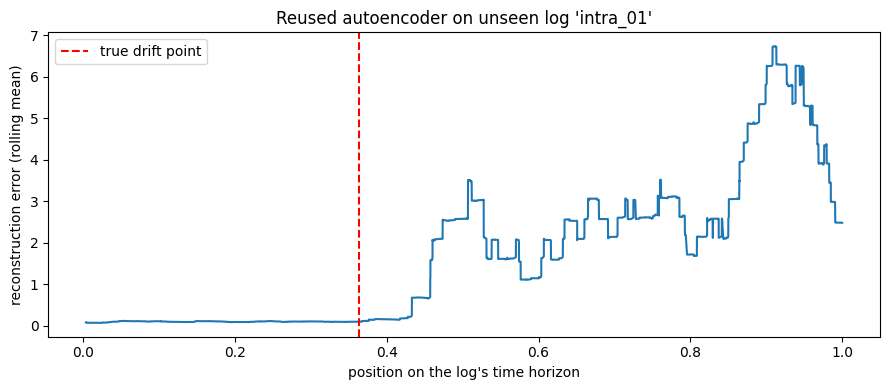

In [28]:
features, keys = log_to_features(DATA_DIR / f"{demo['log']}.xes")
X_demo = torch.from_numpy(reused_scaler.transform(features.to_numpy()))
errors = reconstruction_errors(reused, X_demo)

# order the events by time and place each one on the log's 0..1 time horizon
ts = keys["time:timestamp"]
order = np.argsort(ts.values)
horizon = ((ts - ts.min()) / (ts.max() - ts.min())).values[order]
rolling = pd.Series(errors[order]).rolling(300, min_periods=50).mean()

plt.figure(figsize=(9, 4))
plt.plot(horizon, rolling, lw=1.5)
for drift in demo_drifts:
    if drift["mode"] == "sudden":
        plt.axvline(drift["drift_point"], color="red", ls="--", label="true drift point")
    else:
        plt.axvspan(drift["start_point"], drift["end_point"], color="red", alpha=0.15,
                    label="true drift window")
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys())
plt.xlabel("position on the log's time horizon")
plt.ylabel("reconstruction error (rolling mean)")
plt.title(f"Reused autoencoder on unseen log '{demo['log']}'")
plt.tight_layout()
plt.show()